In [224]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({
    "font.size": 16,        # base font
    "axes.titlesize": 20,   # title
    "axes.labelsize": 18,   # x/y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
    "legend.fontsize": 16,  # legend
})

In [229]:
format_factor = 2.0

def Lambda(x):
    return format_factor * np.exp(-x)

def H(x):
    x = np.asarray(x)
    return format_factor * np.where(x >= -1, np.exp(-(x + 1)), -x)

def F(x):
    x = np.asarray(x)
    return np.where(x >= -1, x + 1, 0.0)

In [230]:
Q = 10
gamma = 0.1
sigma = 1.0
T = 10

V(0,0) = 13.179559061326222
Check terminal condition: V(T,0) = 0.0


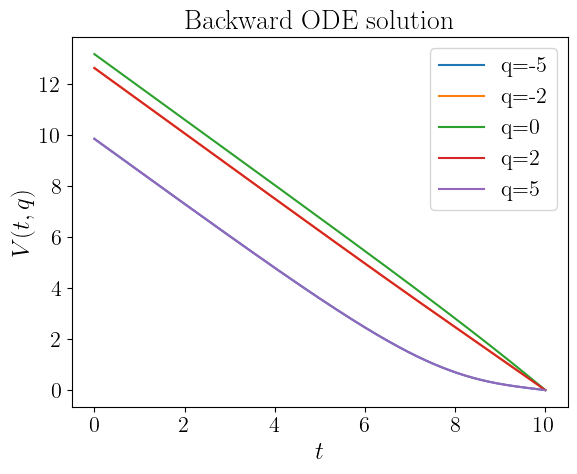

In [231]:
# Inventory grid q in {-Q, ..., Q}
qs = np.arange(-Q, Q + 1, dtype=int)
nqs = len(qs)


# Inventory-penalization term
def running_term(t, q):
    return 0.5 * gamma * sigma**2 * q**2


# RHS of the ODE system
def rhs(t, v):
    dv = np.zeros_like(v)

    for i, q in enumerate(qs):
        val = running_term(t, q)
        if q > -Q:
            val -= H(v[i] - v[i - 1])
        if q < Q:
            val -= H(v[i] - v[i + 1])

        dv[i] = val
    return dv


# Time grid for backward solve (must be decreasing because we solve from T to 0)
t_eval = np.linspace(T, 0.0, 2000)

# Terminal condition vector (v(T,q) = 0 for all q)
vT = np.zeros(nqs)

# Solve backward ODE
sol = solve_ivp(
    fun=rhs,
    t_span=(T, 0.0),
    y0=vT,
    t_eval=t_eval,
)

if not sol.success:
    raise RuntimeError(f"ODE solve failed: {sol.message}")

# Build interpolation helper v_of_t_q(t, q)
ts = sol.t          # descending
vs = sol.y          # shape (nqs, n_t)

# q_to_idx = {q: i for i, q in enumerate(qs)}

q_to_idx = lambda q: q+Q  # since qs = [-Q, ..., Q], we can just shift by Q to get the index

def v_of_t_q(t, q):
    i = q_to_idx(q)
    return np.interp(t, ts[::-1], vs[i, ::-1])


# Checks
print("V(0,0) =", v_of_t_q(0.0, 0))
print("Check terminal condition: V(T,0) =", v_of_t_q(T, 0))


# Plot v(t,q) for a few q values
for q in [-5, -2, 0, 2, 5]:
    i = q_to_idx(q)
    plt.plot(sol.t[::-1], sol.y[i, ::-1], label=f"q={q}")

plt.xlabel(r"$t$")
plt.ylabel(r"$V(t,q)$")
plt.title("Backward ODE solution")
plt.legend()
plt.show()

In [232]:
q0 = 0
S0 = 0.0
x0 = 0.0

dt = 0.01
n_steps = int(T / dt)
time_grid = np.linspace(0.0, T, n_steps + 1)

# Choose how many paths to simulate for the check n_paths = 20000
n_paths = 20000
seed = 12345

# Precompute V(t,q) on the simulation grid
# V_grid shape = (n_steps + 1, n), with time increasing from 0 to T
V_grid = np.empty((n_steps + 1, nqs))
for j, q in enumerate(qs):
    V_grid[:, j] = np.interp(time_grid, ts[::-1], vs[j, ::-1])

# Precompute quote tables
delta_b_table = np.full((n_steps + 1, nqs), np.nan)
delta_a_table = np.full((n_steps + 1, nqs), np.nan)

for q in qs:
    j = q_to_idx(q)
    if q < Q:
        delta_b_table[:, j] = F(V_grid[:, j] - V_grid[:, j + 1])
    if q > -Q:
        delta_a_table[:, j] = F(V_grid[:, j] - V_grid[:, j - 1])


def mc_value_for_q0(q0, n_paths=20000, seed=12345, verbose=False, store_quotes=False):

    rng = np.random.default_rng(seed)
    
    # Simulate optimal strategy and estimate the value
    S = np.full(n_paths, S0, dtype=np.float64)      # asset price
    q = np.full(n_paths, q0, dtype=np.int32)        # inventory
    x = np.full(n_paths, x0, dtype=np.float64)      # cash
    PnL = np.zeros(n_paths, dtype=np.float64)       # PnL
    da = np.zeros(n_steps, dtype=np.float64)        # ask quote
    db = np.zeros(n_steps, dtype=np.float64)        # bid quote
    q_path = np.zeros(n_steps+1, dtype=np.int32)  # store inventory paths for analysis
    q_path[0] = q0
    asset_price_path = np.zeros(n_steps + 1, dtype=np.float64)  # store asset price paths for analysis
    asset_price_path[0] = S0

    # running approximation of integral \int_0^T q_t^2 dt
    inventory_penalty_integral = np.zeros(n_paths, dtype=np.float64)


    for k in range(n_steps):
        # accumulate \int q_t^2 dt using left-point rule
        inventory_penalty_integral += q**2 * dt

        # get index of current inventory level in precomputed tables
        q_idx = q_to_idx(q)

        # get optimal quotes from tables
        delta_b = delta_b_table[k, q_idx]
        delta_a = delta_a_table[k, q_idx]
        
        # compute Poisson intensities for each path
        lambda_b = np.where(q < Q, Lambda(delta_b), 0.0)
        lambda_a = np.where(q > -Q, Lambda(delta_a), 0.0)

        # Poisson draws, capped at 1 per side
        bid_exec = np.minimum(rng.poisson(lambda_b * dt), 1)
        ask_exec = np.minimum(rng.poisson(lambda_a * dt), 1)
        
        # check that bid and ask executions don't happen simultaneously (which would be unrealistic)
        both_exec = (bid_exec == 1) & (ask_exec == 1)
        if np.any(both_exec):
            # randomly keep only one of the two executions for each affected path
            keep_bid = rng.random(size=np.sum(both_exec)) < 0.5
            bid_exec[both_exec] = keep_bid.astype(int)
            ask_exec[both_exec] = (~keep_bid).astype(int)

        # update cash / inventory
        x -= bid_exec * (S - np.nan_to_num(delta_b, nan=0.0))
        q += bid_exec

        x += ask_exec * (S + np.nan_to_num(delta_a, nan=0.0))
        q -= ask_exec

        q = np.clip(q, -Q, Q)

        # mid-price evolution
        S += sigma * np.sqrt(dt) * rng.normal(size=n_paths)
        
        # store quotes of the first path for analysis
        if store_quotes:
            q_path[k + 1] = q[0]
            asset_price_path[k + 1] = S[0]
            da[k] = delta_a[0]
            db[k] = delta_b[0]

    # terminal payoff path by path
    payoff_paths = x + q * S - 0.5 * gamma * sigma**2 * inventory_penalty_integral
    PnL = x + q*S
    # compute mean and standard error of the Monte Carlo estimate for each q0
    mc_mean = np.mean(payoff_paths, axis=0)
    mc_std = np.std(payoff_paths, ddof=1)
    mc_se = mc_std / np.sqrt(n_paths)

    v_theory = V_grid[0, q_to_idx(q0)]

    if verbose:
        print("Number of paths simulated      =", n_paths)
        print("Theoretical value V(0,q0)      =", v_theory)
        print("Monte Carlo estimate           =", mc_mean)
        print("Monte Carlo std                =", mc_std)
        print("Monte Carlo standard error     =", mc_se)
        print("Absolute error                 =", abs(mc_mean - v_theory))
        print("95% confidence interval        = [{:.6f}, {:.6f}]".format(
            mc_mean - 1.96 * mc_se, mc_mean + 1.96 * mc_se
        ))
        print("Is V(0,q0) in the 95% CI?      =", (mc_mean - 1.96 * mc_se <= v_theory <= mc_mean + 1.96 * mc_se))
        
    return {
        "q0": q0,
        "q_path": q_path,
        "S": asset_price_path,
        "Payoff_paths": payoff_paths,
        "PnL": PnL,
        "da": da,
        "db": db,
        "V_theory": v_theory,
        "MC_mean": mc_mean,
        "MC_std": mc_std,
        "MC_se": mc_se,
        "abs_error": abs(mc_mean - v_theory),
        "ci_low": mc_mean - 1.96 * mc_se,
        "ci_high": mc_mean + 1.96 * mc_se,
        "covered": (mc_mean - 1.96 * mc_se <= v_theory <= mc_mean + 1.96 * mc_se),
    }
        
res = mc_value_for_q0(q0, n_paths=20000, seed=12345, verbose=True)

Number of paths simulated      = 20000
Theoretical value V(0,q0)      = 13.179559061326222
Monte Carlo estimate           = 13.033372508437354
Monte Carlo std                = 5.592571034139503
Monte Carlo standard error     = 0.039545449025075056
Absolute error                 = 0.14618655288886728
95% confidence interval        = [12.955863, 13.110882]
Is V(0,q0) in the 95% CI?      = False


In [233]:
q0s = [q0] # initial inventory levels to test
big_result = mc_value_for_q0(q0=q0, n_paths=1_000_000)

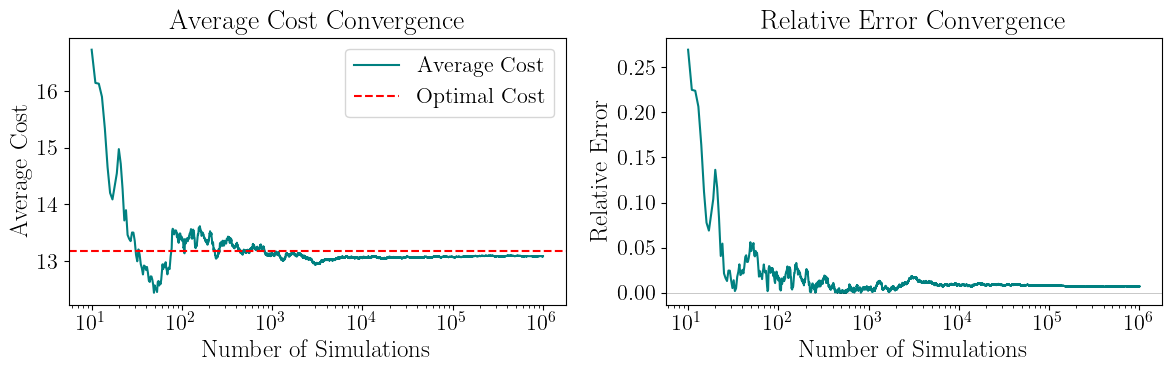

In [234]:
payoffs = big_result["Payoff_paths"]
true_value = big_result["V_theory"]
avgs = np.cumsum(payoffs) / np.arange(1, len(payoffs) + 1)
rel_error = np.abs(avgs - true_value) / np.abs(true_value)
FROM = 10

plt.subplots(1, 2, figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.arange(FROM, payoffs.shape[0] + 1), avgs[FROM-1:], color="teal", label='Average Cost')
plt.axhline(v_of_t_q(0,0), color="r", linestyle='--', label='Optimal Cost')
plt.xscale('log')
plt.title('Average Cost Convergence')
plt.xlabel('Number of Simulations')
plt.ylabel('Average Cost')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.arange(FROM, payoffs.shape[0] + 1), rel_error[FROM-1:], color="teal")
plt.axhline(0, linewidth=.5, color="black", alpha=0.3)
plt.xscale('log')
plt.title('Relative Error Convergence')
plt.xlabel('Number of Simulations')
plt.ylabel('Relative Error')

plt.tight_layout()
plt.savefig("Plots/ct_average_value_convergence.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

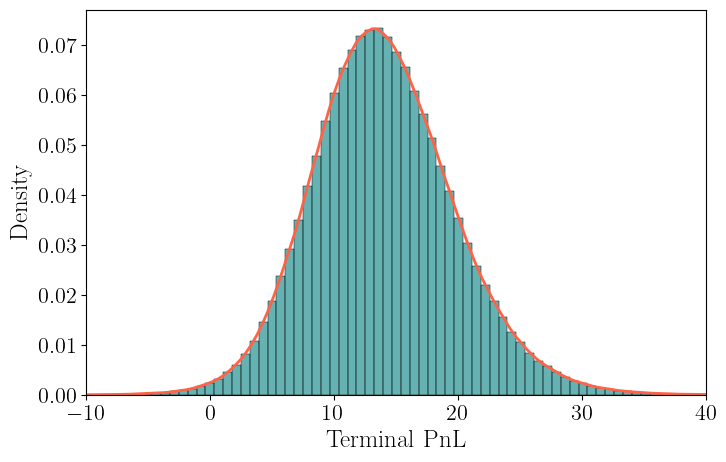

In [238]:
PnL = big_result["PnL"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    PnL,
    bins=120,
    stat="density",
    color="teal",
    alpha=0.6,   # makes it nicer visually
    ax=ax
)

# KDE line (separate, full control)
sns.kdeplot(
    PnL,
    color="tomato",
    linewidth=2,
    ax=ax
)

ax.set_xlabel("Terminal PnL")
ax.set_ylabel("Density")
ax.set_xlim(-10, 40)

plt.savefig("Plots/ct_pnl_distribution.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/hr/wt83vx857tb5stw6bpqw6ss00000gn/T/ipykernel_26640/3707024100.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


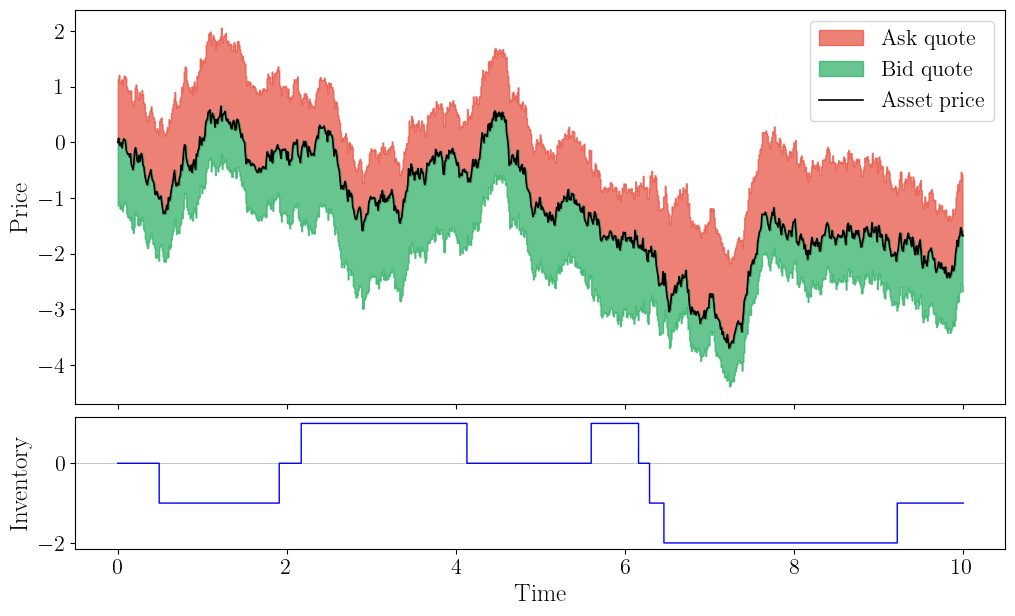

In [252]:
path_for_quotes = mc_value_for_q0(q0=0, n_paths=1, seed=12, store_quotes=True)
q_path = path_for_quotes["q_path"]
asset_price_path = path_for_quotes["S"]
da = path_for_quotes["da"]
db = path_for_quotes["db"]
ASK_COLOR = "#E74C3C"
BID_COLOR = "#27AE60"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                sharex=True,
                                gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
                                )

# --- Top: price + quote flags ---
# ax1.vlines(time_grid[:-1], asset_price_path[:-1], asset_price_path[:-1] + da, linewidth=1.5, alpha=0.7, color=ASK_COLOR, label="Ask quote")
# ax1.vlines(time_grid[:-1], asset_price_path[:-1] - db, asset_price_path[:-1], linewidth=1.5, alpha=0.7, color=BID_COLOR, label="Bid quote")
ax1.fill_between(time_grid[:-1], asset_price_path[:-1], asset_price_path[:-1] + da, step="post", alpha=0.7, color=ASK_COLOR, label="Ask quote")
ax1.fill_between(time_grid[:-1], asset_price_path[:-1] - db, asset_price_path[:-1], step="post", alpha=0.7, color=BID_COLOR, label="Bid quote")
ax1.plot(time_grid, asset_price_path, linewidth=1.2, label="Asset price", color="black")
ax1.set_ylabel("Price")
# ax1.set_title("Optimal quotes as flags on the asset price")
ax1.legend(loc="best")

# --- Bottom: inventory ---
ax2.step(time_grid, q_path, where="post", linewidth=1, color="blue", label=r"Inventory $q$")
ax2.axhline(0, linewidth=.5, color="black", alpha=0.3)
ax2.set_ylabel("Inventory")
ax2.set_xlabel("Time")

fig.tight_layout()
plt.savefig("Plots/ct_optimal_quotes.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

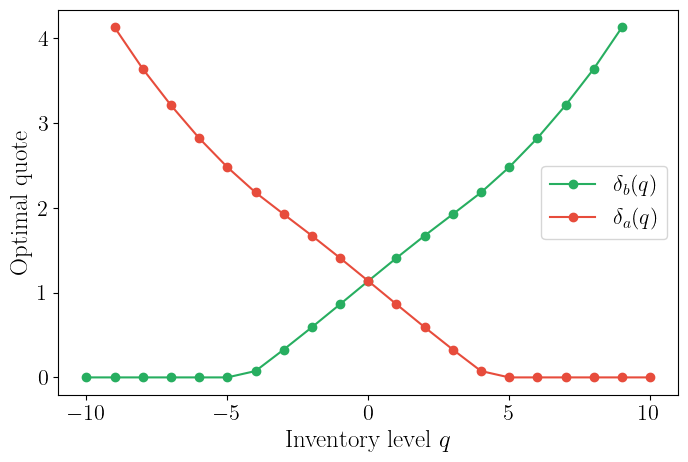

In [248]:
# see how optimal quotes evolve with inventory level at t=0
q_range = np.arange(-Q, Q + 1, dtype=int)
delta_b_0 = delta_b_table[0, q_to_idx(q_range)]
delta_a_0 = delta_a_table[0, q_to_idx(q_range)]
plt.figure(figsize=(8, 5))
plt.plot(q_range, delta_b_0, marker="o", color=BID_COLOR, label=r"$\delta_b(q)$")
plt.plot(q_range, delta_a_0, marker="o", color=ASK_COLOR, label=r"$\delta_a(q)$")
plt.xlabel("Inventory level $q$")
plt.ylabel("Optimal quote")
plt.legend()
plt.xticks(q_range[::5])
plt.savefig("Plots/ct_optimal_quotes_vs_inventory.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()